# Этап 2. Предварительная обработка данных

Цель — подготовить данные для прогноза цены предполагаемой продажи недвижимости. После каждой проверки приведена её интерпретация. Исходный CSV не меняется.

В словаре данных числовые коды listing_type не расшифрованы. По масштабу цен код 1 похож на продажу, код 2 — на аренду; код 3 остаётся неизвестным. Это предположение, которое нужно подтвердить у источника.

## Исходный набор

Источник — data/real_estate_data.csv. Целевая переменная — price (цена объявления). Площадь size измеряется в м².

In [1]:
# Загружаем данные и показываем размер и первые строки.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

ROOT = next((p for p in (Path.cwd(), Path.cwd().parent)
             if (p / "data" / "real_estate_data.csv").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Не найден data/real_estate_data.csv")
raw = pd.read_csv(ROOT / "data" / "real_estate_data.csv", low_memory=False)
print("Размер:", raw.shape)
display(raw.head(3))

Размер: (403487, 17)


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY


В исходном наборе 403 487 строк. Сначала приводим цены к единой валюте, затем разбиваем объявления. Статистики заполнения и кодирования будем получать только из train.

### Приведение цены к одной валюте

Исторические курсы берём из [архива Центрального банка Турции](https://www.tcmb.gov.tr/kurlar/kurlar_en.html). Используется ForexBuying — TRY за единицу иностранной валюты. При отсутствии публикации за выходной берём последний курс до даты объявления (не старше 7 дней). Это справочный, а не фактический курс сделки. Время публикации объявления неизвестно, поэтому курс того же дня мог быть опубликован позже.

In [7]:
# При первом запуске получаем курсы из TCMB и сохраняем локально.
from concurrent.futures import ThreadPoolExecutor
import requests
import xml.etree.ElementTree as ET

rate_file = ROOT / "data" / "external" / "tcmb_rates_2018-2019.csv"
if rate_file.exists():
    rates = pd.read_csv(rate_file)
    
else:
    dates = pd.to_datetime(raw.start_date, format="%m/%d/%y")
    def get_rate(day):
        url = f"https://www.tcmb.gov.tr/kurlar/{day:%Y%m}/{day:%d%m%Y}.xml"
        response = requests.get(url, timeout=20)
        if response.status_code == 404:
            return []
        response.raise_for_status()
        root = ET.fromstring(response.content)
        assert pd.to_datetime(root.attrib["Tarih"], format="%d.%m.%Y") == day
        return [{"rate_date": day, "currency": item.attrib["Kod"],
                 "try_per_unit": float(item.findtext("ForexBuying")) / float(item.findtext("Unit"))}
                for item in root.findall("Currency")
                if item.attrib.get("Kod") in ("EUR", "USD", "GBP")]
    with ThreadPoolExecutor(max_workers=10) as pool:
        daily = pool.map(get_rate, pd.date_range(dates.min()-pd.Timedelta(days=7), dates.max()))
        rates = pd.DataFrame(row for day in daily for row in day)
    rate_file.parent.mkdir(parents=True, exist_ok=True)
    rates.to_csv(rate_file, index=False)
rates["rate_date"] = pd.to_datetime(rates.rate_date)
assert set(rates.currency) == {"EUR", "USD", "GBP"}
assert rates.try_per_unit.gt(0).all()

print("Дней с опубликованными курсами:", rates.rate_date.nunique())
rates.head(10)

Дней с опубликованными курсами: 130


,rate_date,currency,try_per_unit
0,2018-08-27,EUR,7.1875
1,2018-08-28,EUR,7.2744
2,2018-08-29,EUR,7.4735
3,2018-08-31,EUR,7.6428
4,2018-09-03,EUR,7.6868
5,2018-09-04,EUR,7.7252
6,2018-09-05,EUR,7.7336
7,2018-09-06,EUR,7.6573
8,2018-09-07,EUR,7.5259
9,2018-09-10,EUR,7.4635


За нужный период в архиве 130 дней публикации курсов. Проверки подтверждают наличие EUR, USD и GBP и положительность курсов.

In [3]:
# Оставляем код 1 с положительной ценой; иностранные цены умножаем на курс.
sale = raw.loc[raw.listing_type.eq(1) & raw.price.gt(0)].copy()
sale["original_currency"] = sale.price_currency
sale["listing_date"] = pd.to_datetime(sale.start_date, format="%m/%d/%y")
sale["rate_date"] = pd.NaT
sale["fx_rate"] = 1.0
for currency in ("EUR", "USD", "GBP"):
    part = sale.loc[sale.original_currency.eq(currency), ["listing_date"]]
    left = part.sort_values("listing_date").reset_index().rename(columns={"index":"row_id"})
    right = rates.loc[rates.currency.eq(currency), ["rate_date","try_per_unit"]].sort_values("rate_date")
    match = pd.merge_asof(left, right, left_on="listing_date", right_on="rate_date",
                          direction="backward", tolerance=pd.Timedelta(days=7))
    assert match.try_per_unit.notna().all(), f"Курс {currency} не найден"
    sale.loc[match.row_id.to_numpy(), "fx_rate"] = match.try_per_unit.to_numpy()
    sale.loc[match.row_id.to_numpy(), "rate_date"] = match.rate_date.to_numpy()
sale["price"] *= sale.fx_rate
sale["price_currency"] = "TRY"
foreign = sale.original_currency.ne("TRY")
lag = (sale.loc[foreign,"listing_date"]-sale.loc[foreign,"rate_date"]).dt.days
display(sale.groupby("original_currency").price.agg(["size","median"]))
print("Всего:",len(sale),"| пересчитано:",foreign.sum(),
      "| без курса:",sale.loc[foreign,"rate_date"].isna().sum(),
      "| максимальный разрыв:",lag.max(),"дня")
assert len(sale)==286392 and foreign.sum()==1924 and lag.between(0,7).all()

,size,median
original_currency,,
EUR,891,568917.0
GBP,581,537212.7
TRY,284468,270000.0
USD,452,3673835.0


Всего: 286392 | пересчитано: 1924 | без курса: 0 | максимальный разрыв: 3 дня


В итоге 286 392 объявления: 284 468 цен изначально в TRY и 1 924 пересчитаны из EUR, USD и GBP. Пропусков курса нет, максимальный разрыв с датой объявления — 3 дня. Типы 2 и 3 не добавляем: пересчёт валюты не превращает аренду или неизвестный платёж в продажу.

## 2.1. Пропуски и разбиение

Пустую площадь заполним медианой по району и типу жилья, если в группе не меньше 20 известных площадей. Затем — медианой по типу и общей медианой train. Остальные числовые поля заполним медианой, категории — модой. Строки из-за пропусков признаков не удаляем.

In [4]:
# Смотрим, где и сколько пропусков.
missing = pd.DataFrame({"Пропусков":sale.isna().sum(),
                        "Доля, %":sale.isna().mean()*100}).sort_values("Доля, %",ascending=False)
display(missing)
print("Полных дубликатов:", sale.duplicated().sum())

,Пропусков,"Доля, %"
furnished,286392,100.000000
rate_date,284468,99.328194
end_date,103119,36.006243
size,101702,35.511467
floor_no,24721,8.631875
total_floor_count,18314,6.394732
heating_type,18272,6.380066
building_age,17242,6.020420
id,0,0.000000
start_date,0,0.000000


Полных дубликатов: 0


Площадь отсутствует у большой части объявлений. Удаление всех таких строк заметно уменьшило бы выборку, поэтому используем заполнение. Технические, полностью пустые и известные только после публикации поля в модель не включаем.

In [5]:
# Разбиваем до обучения заполнителей и кодировщика.
groups = pd.util.hash_pandas_object(
    sale[["address","sub_type","room_count","size"]],index=False)
first = GroupShuffleSplit(n_splits=1,test_size=.15,random_state=42)
dev_idx,test_idx = next(first.split(sale,groups=groups))
dev = sale.iloc[dev_idx]
second = GroupShuffleSplit(n_splits=1,test_size=.15/.85,random_state=43)
train_idx,val_idx = next(second.split(dev,groups=groups.iloc[dev_idx]))
train,val,test = dev.iloc[train_idx],dev.iloc[val_idx],sale.iloc[test_idx]
parts = (train,val,test)
group_sets = [set(groups.loc[x.index]) for x in parts]
assert all(group_sets[i].isdisjoint(group_sets[j]) for i,j in ((0,1),(0,2),(1,2)))
display(pd.DataFrame({"Часть":["train","validation","test"],
                      "Строк":[len(x) for x in parts],
                      "Доля, %":[100*len(x)/len(sale) for x in parts],
                      "Медиана цены, TRY":[x.price.median() for x in parts]}))

,Часть,Строк,"Доля, %","Медиана цены, TRY"
0,train,200662,70.065505,270000.0
1,validation,42720,14.916618,275000.0
2,test,43010,15.017878,270000.0


Получено разбиение около 70/15/15 с random_state=42. Похожие объявления с одинаковыми адресом, типом, комнатами и площадью не переходят между частями. Это уменьшает риск утечки, но не распознаёт один объект с изменённым описанием.

## 2.2. Выбросы

Площадь менее 15 м² считаем неизвестной. Очень большие площади ограничим по перцентилям 0,1% и 99,9%, вычисленным на train. Положительные цены не обрезаем: часть дорогих объектов может быть реальной.

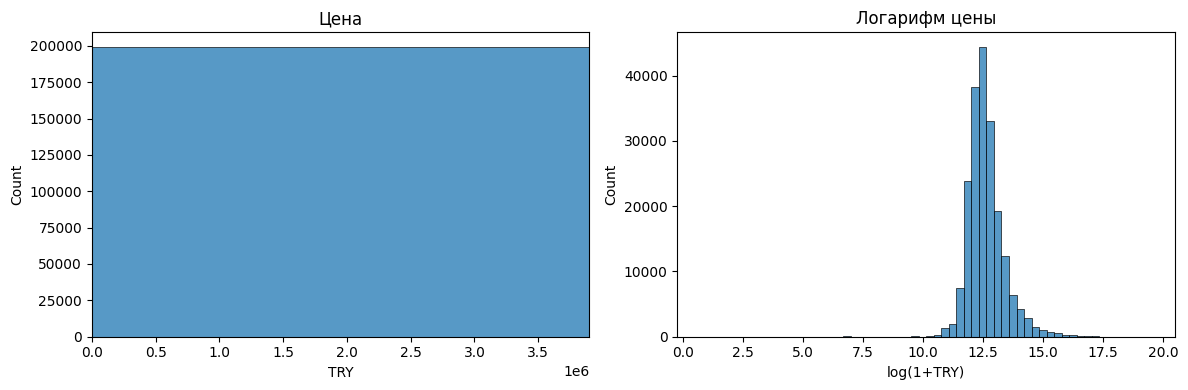

Асимметрия: 70.17


In [6]:
# Сравниваем обычное и логарифмическое распределение цены train.
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.histplot(train.price,bins=60,ax=ax[0])
ax[0].set(title="Цена",xlabel="TRY",xlim=(0,train.price.quantile(.99)))
sns.histplot(np.log1p(train.price),bins=60,ax=ax[1])
ax[1].set(title="Логарифм цены",xlabel="log(1+TRY)")
plt.tight_layout(); plt.show()
print("Асимметрия:",round(train.price.skew(),2))

Цена сильно скошена вправо: основная масса объявлений дешевле редких дорогих объектов. Логарифм помогает увидеть форму распределения, но целевую переменную для оценки оставляем в TRY.

## 2.3–2.4. Кодирование и создание признаков

Запись 3+1 означает три комнаты и одну гостиную. Адрес разделяем на город и район, этаж переводим в число и сравниваем с этажностью, возраст здания — в годы. Цена за м² исключена: она вычисляется из целевой цены и вызвала бы утечку. Расстояние до центра не вычисляем без координат.

In [7]:
# Преобразования ниже не считают статистики и одинаковы для всех частей.
def features(part):
    x=pd.DataFrame(index=part.index)
    a=part.address.fillna("").str.split("/",n=2,expand=True)
    x["city"]=a[0].replace("",np.nan)
    x["district"]=(a[0]+"/"+a[1]).where(a[1].notna())
    r=part.room_count.astype("string").str.extract(r"^(\d+)\+(\d+)$")
    x["bedrooms"]=pd.to_numeric(r[0],errors="coerce")
    x["living_rooms"]=pd.to_numeric(r[1],errors="coerce")
    x["size_m2"]=pd.to_numeric(part["size"],errors="coerce")
    x["size_m2"]=x.size_m2.where(x.size_m2.ge(15))
    x["size_missing"]=x.size_m2.isna().astype(int)
    age=part.building_age.astype("string")
    limits=age.str.extract(r"^(\d+)-(\d+) arası$").apply(pd.to_numeric,errors="coerce")
    x["building_age_years"]=pd.to_numeric(age,errors="coerce").fillna(limits.mean(axis=1)).fillna(age.map({"40 ve üzeri":40}))
    x["age_missing"]=x.building_age_years.isna().astype(int)
    x["is_new_building"]=x.building_age_years.eq(0).fillna(False).astype(int)
    floors=part.total_floor_count.astype("string")
    x["building_floors"]=pd.to_numeric(floors,errors="coerce").fillna(floors.map({"10-20 arası":15,"20 ve üzeri":20}))
    floor=part.floor_no.astype("string")
    x["floor_number"]=pd.to_numeric(floor,errors="coerce").fillna(floor.map({"Yüksek Giriş":1,"Giriş Katı":0,"Zemin Kat":0,"Bahçe katı":0,"20 ve üzeri":20}))
    basement=pd.to_numeric(floor.str.extract(r"^Kot (\d+)$")[0],errors="coerce")
    x["floor_number"]=x.floor_number.fillna(-basement)
    x["floor_ratio"]=x.floor_number/x.building_floors.where(x.building_floors.gt(0))
    x["is_top_floor"]=(x.floor_number.eq(x.building_floors)&x.building_floors.notna()).fillna(False).astype(int)
    x["sub_type"]=part.sub_type
    x["heating_type"]=part.heating_type
    return x
X_train,X_val,X_test=[features(part) for part in parts]
y_train,y_val,y_test=[part.price.copy() for part in parts]
display(X_train.head(3))

,city,district,bedrooms,living_rooms,size_m2,size_missing,building_age_years,age_missing,is_new_building,building_floors,floor_number,floor_ratio,is_top_floor,sub_type,heating_type
2,Tekirdağ,Tekirdağ/Çorlu,2,1,NaN,1,0,0,1,1,1,1.0,1,Daire,Fancoil
3,İstanbul,İstanbul/Beşiktaş,6,1,450.0,0,3,0,0,20,20,1.0,1,Rezidans,Fancoil
4,İstanbul,İstanbul/Kartal,2,1,90.0,0,0,0,1,20,2,0.1,0,Rezidans,Fancoil


Первые строки показывают новые числовые признаки. Ни цена, ни курс, ни ID, ни дата снятия объявления в таблицу признаков не попали.

In [8]:
# Учим медианы площади только на train и применяем ко всем частям.
by_group=X_train.groupby(["district","sub_type"]).size_m2.agg(["median","count"])
by_group=by_group.loc[by_group["count"].ge(20),"median"]
by_type=X_train.groupby("sub_type").size_m2.median()
overall=X_train.size_m2.median()
def fill_area(x):
    result=x.copy()
    keys=pd.MultiIndex.from_frame(result[["district","sub_type"]])
    local=pd.Series(by_group.reindex(keys).to_numpy(),index=result.index)
    result["size_m2"]=result.size_m2.fillna(local).fillna(result.sub_type.map(by_type)).fillna(overall)
    return result
before=[x.size_m2.isna().sum() for x in (X_train,X_val,X_test)]
X_train,X_val,X_test=[fill_area(x) for x in (X_train,X_val,X_test)]
display(pd.DataFrame({"Часть":["train","validation","test"],
                      "Пропусков площади до":before,
                      "После":[x.size_m2.isna().sum() for x in (X_train,X_val,X_test)]}))
print("Общая медиана train:",overall)

,Часть,Пропусков площади до,После
0,train,72109,0
1,validation,14396,0
2,test,15541,0


Общая медиана train: 115.0


Пропуски площади заполнены без удаления строк. Медианы районов и типов жилья вычислены по train; validation и test только преобразованы.

In [9]:
# Пороги площади также получаем только из train.
low,high=X_train.size_m2.quantile([.001,.999])
for x in (X_train,X_val,X_test):
    x["size_m2"]=x.size_m2.clip(low,high)
print("Границы площади, м²:",round(low,1),"—",round(high,1))

Границы площади, м²: 30.0 — 2363.6


Площадь ограничена одинаково во всех трёх частях. Строки не удалены, целевая цена не изменена.

## 2.5. Кодирование и масштабирование

Город, район, тип жилья и отопление — номинальные категории, поэтому применяем One-Hot Encoding. Редкие категории объединяем. Для линейной модели числа стандартизируем; для деревьев оставляем без масштабирования.

In [10]:
# Все заполнители, кодировщик и скалер обучаются только на train.
num=["size_m2","bedrooms","living_rooms","building_age_years","building_floors",
     "floor_number","floor_ratio","size_missing","age_missing","is_new_building","is_top_floor"]
cat=["city","district","sub_type","heating_type"]
def build_encoder(scale):
    steps=[("missing",SimpleImputer(strategy="median"))]
    if scale: steps.append(("scale",StandardScaler()))
    return ColumnTransformer([
        ("num",Pipeline(steps),num),
        ("cat",Pipeline([("missing",SimpleImputer(strategy="most_frequent")),
                         ("onehot",OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                 min_frequency=100))]),cat)
    ],sparse_threshold=.3)
linear_preprocessor=build_encoder(True)
tree_preprocessor=build_encoder(False)
X_train_linear=linear_preprocessor.fit_transform(X_train)
X_val_linear=linear_preprocessor.transform(X_val)
X_test_linear=linear_preprocessor.transform(X_test)
X_train_tree=tree_preprocessor.fit_transform(X_train)
X_val_tree=tree_preprocessor.transform(X_val)
X_test_tree=tree_preprocessor.transform(X_test)
display(pd.DataFrame({"Часть":["train","validation","test"],
                      "Строк":[x.shape[0] for x in (X_train_linear,X_val_linear,X_test_linear)],
                      "Признаков":[x.shape[1] for x in (X_train_linear,X_val_linear,X_test_linear)]}))

,Часть,Строк,Признаков
0,train,200662,316
1,validation,42720,316
2,test,43010,316


Число столбцов совпадает во всех частях: новые категории не ломают обработку. Важное правило для следующего этапа: при кросс-валидации кодировщик и заполнители должны обучаться внутри каждого тренировочного фолда.

## 2.6. Проверка результата

Проверяем конечность значений и мультиколлинеарность основных числовых признаков с помощью VIF. Новые признаки сами по себе не гарантируют отсутствие корреляции.

In [11]:
from scipy import sparse
for matrix in (X_train_linear,X_val_linear,X_test_linear,X_train_tree,X_val_tree,X_test_tree):
    values=matrix.data if sparse.issparse(matrix) else np.asarray(matrix)
    assert np.isfinite(values).all()
vif_cols=["size_m2","bedrooms","living_rooms","building_age_years",
          "building_floors","floor_number","floor_ratio"]
vif_data=pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_train[vif_cols]),
                      columns=vif_cols).sample(n=min(20000,len(X_train)),random_state=42)
vif_matrix=np.column_stack([np.ones(len(vif_data)),vif_data.to_numpy()])
vif=pd.DataFrame({"Признак":vif_cols,
                  "VIF":[variance_inflation_factor(vif_matrix,i+1) for i in range(len(vif_cols))]})
display(vif.sort_values("VIF",ascending=False))
print("Максимальный VIF:",round(vif.VIF.max(),2))
print("NaN и бесконечностей в итоговых матрицах нет")

,Признак,VIF
5,floor_number,4.090790
6,floor_ratio,2.598534
4,building_floors,2.579709
1,bedrooms,1.364915
0,size_m2,1.246947
2,living_rooms,1.133170
3,building_age_years,1.015088


Максимальный VIF: 4.09
NaN и бесконечностей в итоговых матрицах нет


Матрицы не содержат пропусков и бесконечностей. Если все VIF ниже 5, существенной мультиколлинеарности среди этих числовых признаков не обнаружено; окончательный выбор признаков сделаем по результатам моделей.

In [12]:
# Сохраняем ID частей для одинаковых экспериментов всей команды.
split_ids=pd.concat([
    pd.DataFrame({"id":train.id,"split":"train"}),
    pd.DataFrame({"id":val.id,"split":"validation"}),
    pd.DataFrame({"id":test.id,"split":"test"})
]).sort_values("id")
out=ROOT/"data"/"processed"/"split_ids.csv"
out.parent.mkdir(parents=True,exist_ok=True)
split_ids.to_csv(out,index=False)
assert len(split_ids)==len(sale) and split_ids.id.is_unique
print("Сохранено",len(split_ids),"ID:",out)

Сохранено 286392 ID: C:\ForesightEstate\data\processed\split_ids.csv


## Итог этапа 2.0

- Все 1 924 валютных объявления пересчитаны в TRY по историческим курсам; Мы прогнозируем цену объявления, а не фактическую цену сделки. итог - 286 392 записей.
- Train, validation и test разделены по группам похожих объявлений, их ID сохранены.
- Пропуски площади заполнены медианами train; экстремальная площадь ограничена порогами train.
- Комнаты, возраст и этаж приведены к числам; категории закодированы One-Hot.
- Для линейной модели числовые признаки стандартизированы, для дерева - нет.
- Все параметры преобразований обучены на train.

